In [29]:
import os
import shutil
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model


In [4]:
# Ruta a la carpeta original con las 25k imágenes
original_dir = r"C:\Users\Work\Downloads\dogs-vs-cats\dogs-vs-cats\train"   # <-- CAMBIA ESTO

base_dir = r"C:\Users\Work\Documents\GitHub\Gupir11-machine-learning\data\raw"        # carpeta nueva para estructura
os.makedirs(base_dir, exist_ok=True)

train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

for d in [train_dir, val_dir, test_dir]:
    os.makedirs(d, exist_ok=True)
    os.makedirs(os.path.join(d, "cats"), exist_ok=True)
    os.makedirs(os.path.join(d, "dogs"), exist_ok=True)

# Listas de archivos
all_cats = [f for f in os.listdir(original_dir) if f.startswith("cat")]
all_dogs = [f for f in os.listdir(original_dir) if f.startswith("dog")]

random.shuffle(all_cats)
random.shuffle(all_dogs)

# Porcentajes de split
n_train = int(0.7 * len(all_cats))   # 70% train
n_val   = int(0.15 * len(all_cats))  # 15% val, 15% test

def copiar(lista_archivos, clase):
    # train
    for f in lista_archivos[:n_train]:
        src = os.path.join(original_dir, f)
        dst = os.path.join(train_dir, clase, f)
        shutil.copyfile(src, dst)
    # val
    for f in lista_archivos[n_train:n_train+n_val]:
        src = os.path.join(original_dir, f)
        dst = os.path.join(val_dir, clase, f)
        shutil.copyfile(src, dst)
    # test
    for f in lista_archivos[n_train+n_val:]:
        src = os.path.join(original_dir, f)
        dst = os.path.join(test_dir, clase, f)
        shutil.copyfile(src, dst)

copiar(all_cats, "cats")
copiar(all_dogs, "dogs")


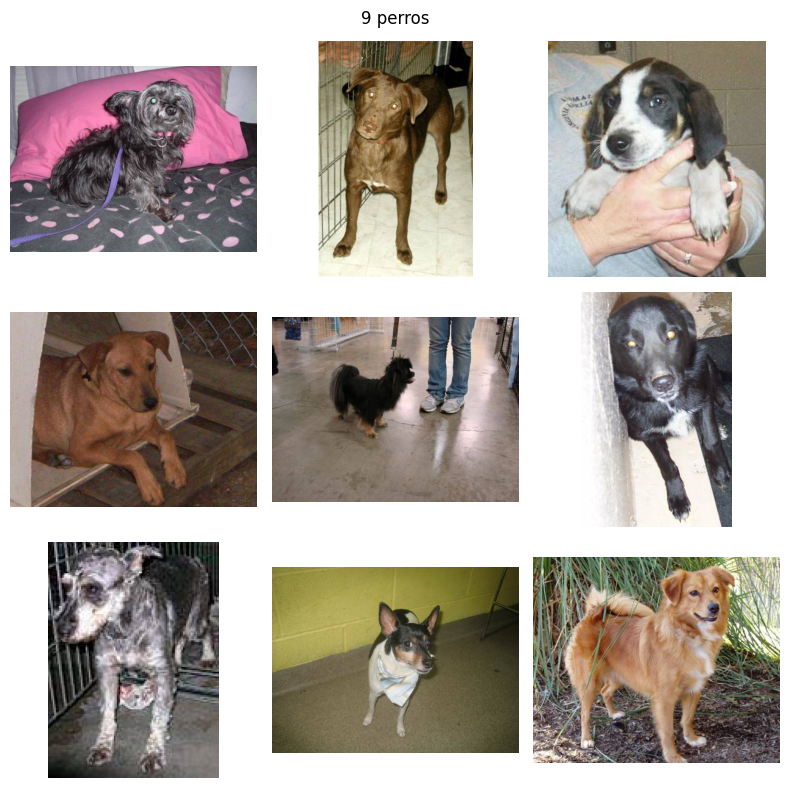

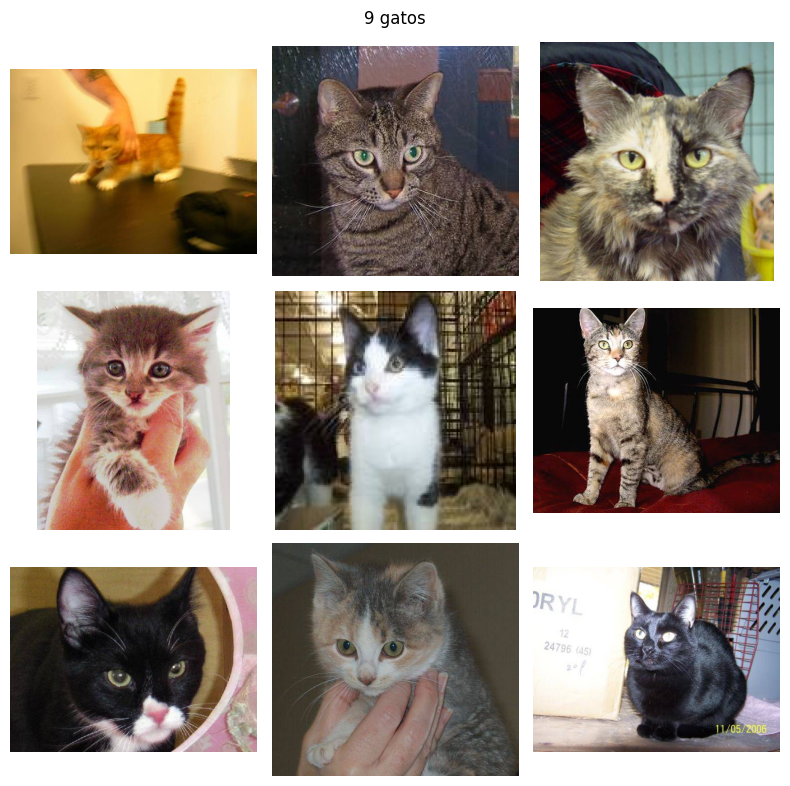

In [5]:
train_cats_dir = os.path.join(train_dir, "cats")
train_dogs_dir = os.path.join(train_dir, "dogs")

# Tomamos 9 archivos de cada clase
dog_files = sorted(os.listdir(train_dogs_dir))[:9]
cat_files = sorted(os.listdir(train_cats_dir))[:9]

def mostrar_9_imagenes(carpeta, lista_archivos, titulo):
    plt.figure(figsize=(8, 8))
    for i, fname in enumerate(lista_archivos):
        img_path = os.path.join(carpeta, fname)
        img = mpimg.imread(img_path)
        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()

mostrar_9_imagenes(train_dogs_dir, dog_files, "9 perros")
mostrar_9_imagenes(train_cats_dir, cat_files, "9 gatos")

In [6]:
IMG_SIZE = 200
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Clases mapeadas:", train_generator.class_indices)


Found 24943 images belonging to 2 classes.
Found 13864 images belonging to 2 classes.
Found 13950 images belonging to 2 classes.
Clases mapeadas: {'cats': 0, 'dogs': 1}


In [22]:
model = Sequential()

# Bloque 1
model.add(Conv2D(32, (3,3), activation="relu", padding="same",
                 input_shape=(200, 200, 3)))
model.add(MaxPooling2D((2,2)))

# Bloque 2
model.add(Conv2D(64, (3,3), activation="relu", padding="same"))
model.add(MaxPooling2D((2,2)))

# Bloque 3
model.add(Conv2D(128, (3,3), activation="relu", padding="same"))
model.add(MaxPooling2D((2,2)))

# Clasificador
model.add(Flatten())
model.add(Dense(256, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(2, activation="softmax"))

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │    20,480,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,574,018 (78.48 MB)

 Trainable params: 20,574,018 (78.48 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3),
    ModelCheckpoint("best_model.h5", monitor="val_accuracy", save_best_only=True)
]

EPOCHS = 30

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)


Epoch 1/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 355s 452ms/step - accuracy: 0.8192 - loss: 0.4005 - val_accuracy: 0.8446 - val_loss: 0.3476
Epoch 2/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 352s 452ms/step - accuracy: 0.8252 - loss: 0.3884 - val_accuracy: 0.8495 - val_loss: 0.3355
Epoch 3/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 354s 454ms/step - accuracy: 0.8333 - loss: 0.3751 - val_accuracy: 0.8463 - val_loss: 0.3519
Epoch 4/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 352s 451ms/step - accuracy: 0.8366 - loss: 0.3637 - val_accuracy: 0.8609 - val_loss: 0.3182
Epoch 5/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 353s 452ms/step - accuracy: 0.8438 - loss: 0.3560 - val_accuracy: 0.8711 - val_loss: 0.2984
Epoch 6/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 352s 451ms/step - accuracy: 0.8491 - loss: 0.3469 - val_accuracy: 0.8618 - val_loss: 0.3239
Epoch 7/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 349s 447ms/step - accuracy: 0.8481 - loss: 0.3433 - val_accuracy: 0.8768 - val_loss: 0.2980
Epoch 8/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 348s 446ms/step - accuracy: 0.8559 -

In [32]:
checkpoint_path = "mejor_modelo.h5"

checkpoint = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,          # nº de epochs sin mejorar antes de parar
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9111 - loss: 0.2185
Epoch 1: val_accuracy improved from None to 0.92967, saving model to mejor_modelo.h5


780/780 ━━━━━━━━━━━━━━━━━━━━ 357s 458ms/step - accuracy: 0.9102 - loss: 0.2202 - val_accuracy: 0.9297 - val_loss: 0.1785
Epoch 2/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.9116 - loss: 0.2178
Epoch 2: val_accuracy did not improve from 0.92967
780/780 ━━━━━━━━━━━━━━━━━━━━ 368s 472ms/step - accuracy: 0.9126 - loss: 0.2155 - val_accuracy: 0.9293 - val_loss: 0.1719
Epoch 3/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.9117 - loss: 0.2172
Epoch 3: val_accuracy improved from 0.92967 to 0.93263, saving model to mejor_modelo.h5


780/780 ━━━━━━━━━━━━━━━━━━━━ 373s 478ms/step - accuracy: 0.9108 - loss: 0.2134 - val_accuracy: 0.9326 - val_loss: 0.1654
Epoch 4/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.9151 - loss: 0.2099
Epoch 4: val_accuracy did not improve from 0.93263
780/780 ━━━━━━━━━━━━━━━━━━━━ 345s 442ms/step - accuracy: 0.9133 - loss: 0.2137 - val_accuracy: 0.9310 - val_loss: 0.1751
Epoch 5/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.9135 - loss: 0.2088
Epoch 5: val_accuracy did not improve from 0.93263
780/780 ━━━━━━━━━━━━━━━━━━━━ 358s 459ms/step - accuracy: 0.9148 - loss: 0.2071 - val_accuracy: 0.9228 - val_loss: 0.1894
Epoch 6/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.9161 - loss: 0.2034
Epoch 6: val_accuracy improved from 0.93263 to 0.93761, saving model to mejor_modelo.h5


780/780 ━━━━━━━━━━━━━━━━━━━━ 369s 473ms/step - accuracy: 0.9173 - loss: 0.2034 - val_accuracy: 0.9376 - val_loss: 0.1549
Epoch 7/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9213 - loss: 0.1947
Epoch 7: val_accuracy improved from 0.93761 to 0.93826, saving model to mejor_modelo.h5


780/780 ━━━━━━━━━━━━━━━━━━━━ 383s 491ms/step - accuracy: 0.9193 - loss: 0.1961 - val_accuracy: 0.9383 - val_loss: 0.1592
Epoch 8/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.9199 - loss: 0.1904
Epoch 8: val_accuracy improved from 0.93826 to 0.93847, saving model to mejor_modelo.h5


...

780/780 ━━━━━━━━━━━━━━━━━━━━ 361s 462ms/step - accuracy: 0.9253 - loss: 0.1854 - val_accuracy: 0.9445 - val_loss: 0.1413
Epoch 13/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.9292 - loss: 0.1808
Epoch 13: val_accuracy did not improve from 0.94453
780/780 ━━━━━━━━━━━━━━━━━━━━ 347s 445ms/step - accuracy: 0.9270 - loss: 0.1823 - val_accuracy: 0.9393 - val_loss: 0.1512
Epoch 14/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.9292 - loss: 0.1738
Epoch 14: val_accuracy improved from 0.94453 to 0.94742, saving model to mejor_modelo.h5


780/780 ━━━━━━━━━━━━━━━━━━━━ 363s 466ms/step - accuracy: 0.9261 - loss: 0.1807 - val_accuracy: 0.9474 - val_loss: 0.1388
Epoch 15/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.9269 - loss: 0.1821
Epoch 15: val_accuracy did not improve from 0.94742
780/780 ━━━━━━━━━━━━━━━━━━━━ 354s 453ms/step - accuracy: 0.9251 - loss: 0.1830 - val_accuracy: 0.9437 - val_loss: 0.1416
Epoch 16/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.9295 - loss: 0.1749
Epoch 16: val_accuracy did not improve from 0.94742
780/780 ━━━━━━━━━━━━━━━━━━━━ 364s 467ms/step - accuracy: 0.9313 - loss: 0.1745 - val_accuracy: 0.9429 - val_loss: 0.1474
Epoch 17/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.9282 - loss: 0.1792
Epoch 17: val_accuracy did not improve from 0.94742
780/780 ━━━━━━━━━━━━━━━━━━━━ 370s 474ms/step - accuracy: 0.9286 - loss: 0.1776 - val_accuracy: 0.9436 - val_loss: 0.1407
Epoch 18/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.9287 - loss: 0.1758
Epoc

780/780 ━━━━━━━━━━━━━━━━━━━━ 375s 480ms/step - accuracy: 0.9302 - loss: 0.1750 - val_accuracy: 0.9524 - val_loss: 0.1249
Epoch 19/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.9298 - loss: 0.1724
Epoch 19: val_accuracy did not improve from 0.95239
780/780 ━━━━━━━━━━━━━━━━━━━━ 343s 440ms/step - accuracy: 0.9322 - loss: 0.1705 - val_accuracy: 0.9432 - val_loss: 0.1424
Epoch 20/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.9353 - loss: 0.1637
Epoch 20: val_accuracy improved from 0.95239 to 0.95434, saving model to mejor_modelo.h5


780/780 ━━━━━━━━━━━━━━━━━━━━ 355s 455ms/step - accuracy: 0.9344 - loss: 0.1662 - val_accuracy: 0.9543 - val_loss: 0.1191
Epoch 21/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.9330 - loss: 0.1631
Epoch 21: val_accuracy did not improve from 0.95434
780/780 ━━━━━━━━━━━━━━━━━━━━ 345s 442ms/step - accuracy: 0.9340 - loss: 0.1635 - val_accuracy: 0.9516 - val_loss: 0.1258
Epoch 22/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.9316 - loss: 0.1669
Epoch 22: val_accuracy did not improve from 0.95434
780/780 ━━━━━━━━━━━━━━━━━━━━ 363s 466ms/step - accuracy: 0.9326 - loss: 0.1662 - val_accuracy: 0.9520 - val_loss: 0.1207
Epoch 23/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9365 - loss: 0.1547
Epoch 23: val_accuracy improved from 0.95434 to 0.95463, saving model to mejor_modelo.h5


780/780 ━━━━━━━━━━━━━━━━━━━━ 375s 481ms/step - accuracy: 0.9349 - loss: 0.1609 - val_accuracy: 0.9546 - val_loss: 0.1197
Epoch 24/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.9361 - loss: 0.1639
Epoch 24: val_accuracy did not improve from 0.95463
780/780 ━━━━━━━━━━━━━━━━━━━━ 345s 443ms/step - accuracy: 0.9359 - loss: 0.1625 - val_accuracy: 0.9481 - val_loss: 0.1292
Epoch 25/30
780/780 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.9376 - loss: 0.1576
Epoch 25: val_accuracy did not improve from 0.95463
780/780 ━━━━━━━━━━━━━━━━━━━━ 356s 457ms/step - accuracy: 0.9378 - loss: 0.1569 - val_accuracy: 0.9526 - val_loss: 0.1201
Epoch 25: early stopping
Restoring model weights from the end of the best epoch: 20.


In [33]:
mejor_modelo = load_model(checkpoint_path)

test_loss, test_acc = mejor_modelo.evaluate(test_generator)
print(f"Pérdida en test: {test_loss:.4f}")
print(f"Accuracy en test: {test_acc:.4f}")

 59/436 ━━━━━━━━━━━━━━━━━━━━ 2:02 325ms/step - accuracy: 0.9291 - loss: 0.1683

ResourceExhaustedError: Graph execution error:

Detected at node PyFunc defined at (most recent call last):
<stack traces unavailable>
MemoryError: Unable to allocate 14.6 MiB for an array with shape (32, 200, 200, 3) and data type float32
Traceback (most recent call last):

  File "c:\Users\Work\Documents\GitHub\Gupir11-machine-learning\tf_env\Lib\site-packages\tensorflow\python\ops\script_ops.py", line 269, in __call__
    ret = func(*args)
          ^^^^^^^^^^^

  File "c:\Users\Work\Documents\GitHub\Gupir11-machine-learning\tf_env\Lib\site-packages\tensorflow\python\autograph\impl\api.py", line 643, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^

  File "c:\Users\Work\Documents\GitHub\Gupir11-machine-learning\tf_env\Lib\site-packages\tensorflow\python\data\ops\from_generator_op.py", line 198, in generator_py_func
    values = next(generator_state.get_iterator(iterator_id))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

  File "c:\Users\W